# DP vs RL Convergence Comparison

Load saved results from `dp_results.pkl` and `rl_results.pkl`, then compare whether DP and RL methods converge to the same policy.

## Strategy
1. Load DP and RL results
2. Utility over time (all methods)
3. Wealth over time (all methods)
4. Allocation trends (DP solid, RL dashed)
5. Summary table
6. Conclusion

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from utils import cara_utility

plt.style.use('seaborn-v0_8-whitegrid')

SCENARIOS = {
    'Base (n=3, T=5)': {
        'n': 3, 'T': 5, 'r': 0.03, 'A': 0.5,
        'a_k': [0.08, 0.06, 0.10],
        's_k': [0.02, 0.015, 0.04],
        'p_init': [0.25, 0.25, 0.25, 0.25],
    },
    'Two Assets (n=2, T=5)': {
        'n': 2, 'T': 5, 'r': 0.03, 'A': 0.7,
        'a_k': [0.09, 0.14],
        's_k': [0.02, 0.04],
        'p_init': [0.50, 0.25, 0.25],
    },
    'Four Assets (n=4, T=5)': {
        'n': 4, 'T': 5, 'r': 0.03, 'A': 0.5,
        'a_k': [0.08, 0.06, 0.10, 0.07],
        's_k': [0.02, 0.015, 0.04, 0.025],
        'p_init': [0.20, 0.20, 0.20, 0.20, 0.20],
    },
    'Four Assets Long (n=4, T=7)': {
        'n': 4, 'T': 7, 'r': 0.02, 'A': 0.7,
        'a_k': [0.06, 0.08, 0.10, 0.13],
        's_k': [0.015, 0.02, 0.025, 0.04],
        'p_init': [0.40, 0.15, 0.15, 0.15, 0.15],
    },
    'Long Horizon (n=3, T=9)': {
        'n': 3, 'T': 9, 'r': 0.03, 'A': 0.5,
        'a_k': [0.08, 0.06, 0.10],
        's_k': [0.02, 0.015, 0.04],
        'p_init': [0.25, 0.25, 0.25, 0.25],
    },
    'High Risk Aversion (A=3.0)': {
        'n': 3, 'T': 5, 'r': 0.03, 'A': 3.0,
        'a_k': [0.08, 0.10, 0.12],
        's_k': [0.02, 0.025, 0.03],
        'p_init': [0.50, 0.20, 0.15, 0.15],
    },
    'Low Risk Aversion (A=0.1)': {
        'n': 3, 'T': 5, 'r': 0.03, 'A': 0.1,
        'a_k': [0.08, 0.10, 0.12],
        's_k': [0.02, 0.025, 0.03],
        'p_init': [0.50, 0.20, 0.15, 0.15],
    },
}

print(f"Defined {len(SCENARIOS)} scenarios")

Defined 7 scenarios


## 1. Load DP and RL Results

In [2]:
# Load DP results
dp_results = {}
if os.path.exists('dp_results.pkl'):
    with open('dp_results.pkl', 'rb') as f:
        dp_saved = pickle.load(f)
    dp_results = dp_saved['results']
    print(f"Loaded DP results for {len(dp_results)} scenarios")
else:
    print("ERROR: No DP results found. Run DP.ipynb first!")

# Load RL results
rl_results = {}
if os.path.exists('rl_results.pkl'):
    with open('rl_results.pkl', 'rb') as f:
        rl_saved = pickle.load(f)
    rl_results = rl_saved['results']
    print(f"Loaded RL results for {len(rl_results)} scenarios")
else:
    print("ERROR: No RL results found. Run RL.ipynb first!")

# Combine into all_results
all_results = {}
for scenario_name in SCENARIOS:
    all_results[scenario_name] = {}
    if scenario_name in dp_results:
        for method, res in dp_results[scenario_name].items():
            all_results[scenario_name][method] = res
    if scenario_name in rl_results:
        for method, res in rl_results[scenario_name].items():
            all_results[scenario_name][method] = res

print(f"\nCombined results:")
for name in all_results:
    print(f"  {name}: {list(all_results[name].keys())}")

Loaded DP results for 7 scenarios
Loaded RL results for 7 scenarios

Combined results:
  Base (n=3, T=5): ['Hold', 'Heuristic', 'Tabular DP', 'ADP-Hermite', 'ADP-MC', 'PPO', 'A2C']
  Two Assets (n=2, T=5): ['Hold', 'Heuristic', 'Tabular DP', 'ADP-Hermite', 'ADP-MC', 'PPO', 'A2C']
  Four Assets (n=4, T=5): ['Hold', 'Heuristic', 'Tabular DP', 'ADP-Hermite', 'ADP-MC', 'PPO', 'A2C']
  Four Assets Long (n=4, T=7): ['Hold', 'Heuristic', 'Tabular DP', 'ADP-Hermite', 'ADP-MC', 'PPO', 'A2C']
  Long Horizon (n=3, T=9): ['Hold', 'Heuristic', 'Tabular DP', 'ADP-Hermite', 'ADP-MC', 'PPO', 'A2C']
  High Risk Aversion (A=3.0): ['Hold', 'Heuristic', 'Tabular DP', 'ADP-Hermite', 'ADP-MC', 'PPO', 'A2C']
  Low Risk Aversion (A=0.1): ['Hold', 'Heuristic', 'Tabular DP', 'ADP-Hermite', 'ADP-MC', 'PPO', 'A2C']


## 2. Visualizations

In [3]:
colors = {
    'Hold': 'gray', 'Heuristic': 'brown',
    'Tabular DP': 'tab:blue', 'ADP-Hermite': 'tab:green',
    'ADP-MC': 'tab:cyan', 'PPO': 'tab:orange', 'A2C': 'tab:red',
}
linestyles = {
    'Hold': ':', 'Heuristic': ':',
    'Tabular DP': '-', 'ADP-Hermite': '-',
    'ADP-MC': '-', 'PPO': '--', 'A2C': '--',
}
markers = {
    'Hold': 'x', 'Heuristic': '+',
    'Tabular DP': 's', 'ADP-Hermite': 'o',
    'ADP-MC': '^', 'PPO': 'D', 'A2C': 'v',
}

### Utility Over Time

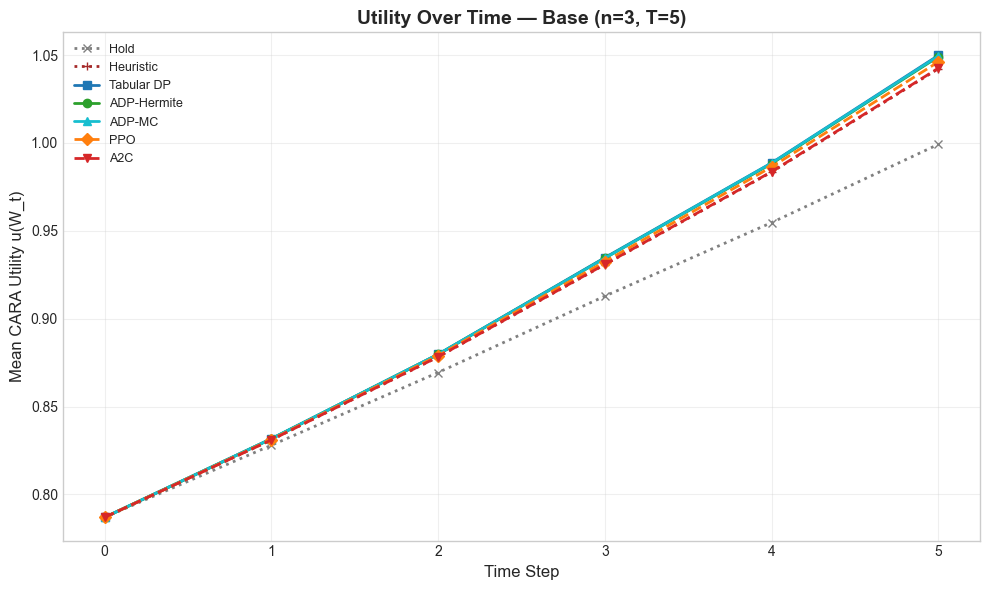

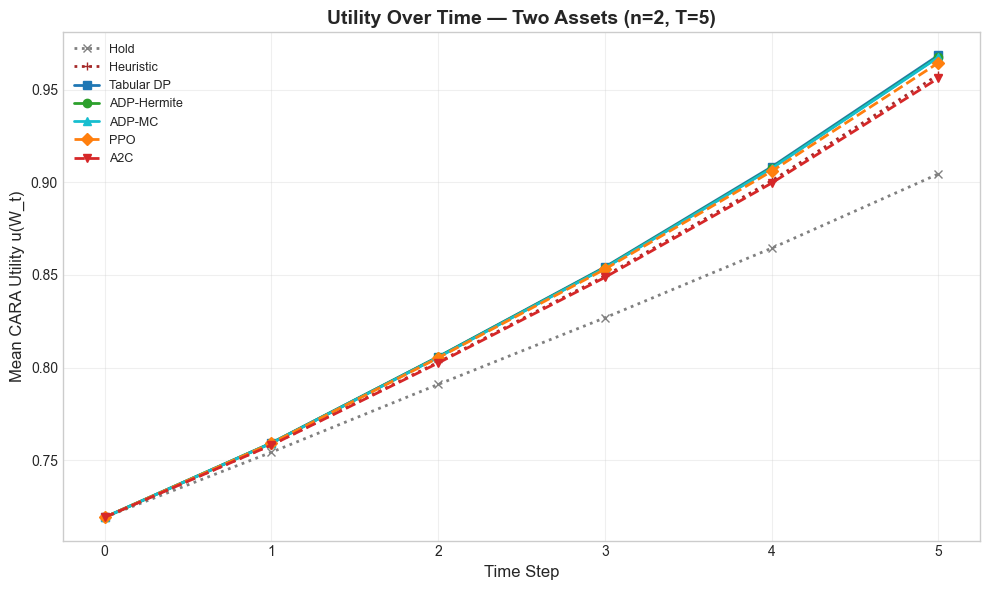

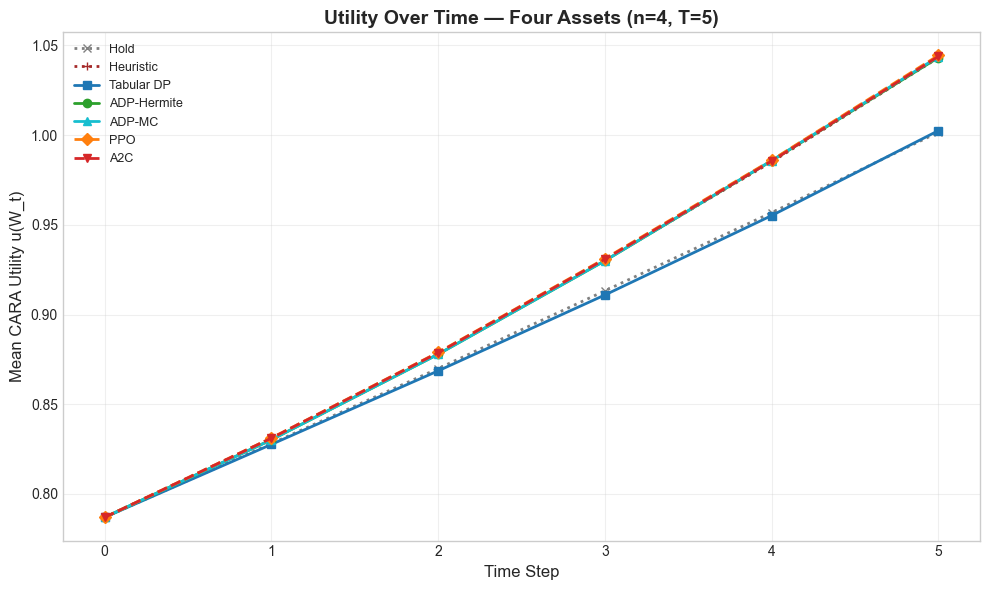

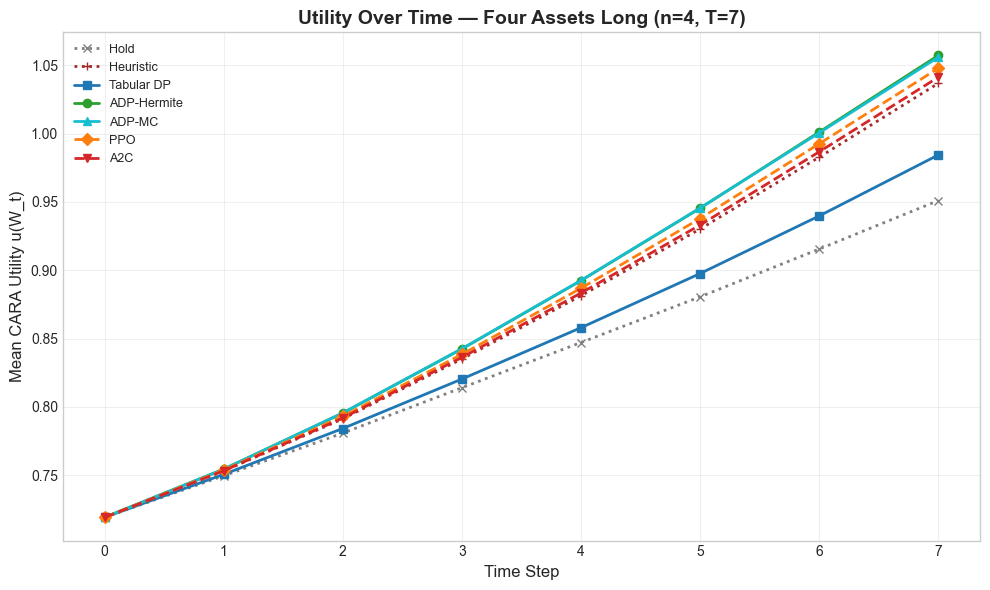

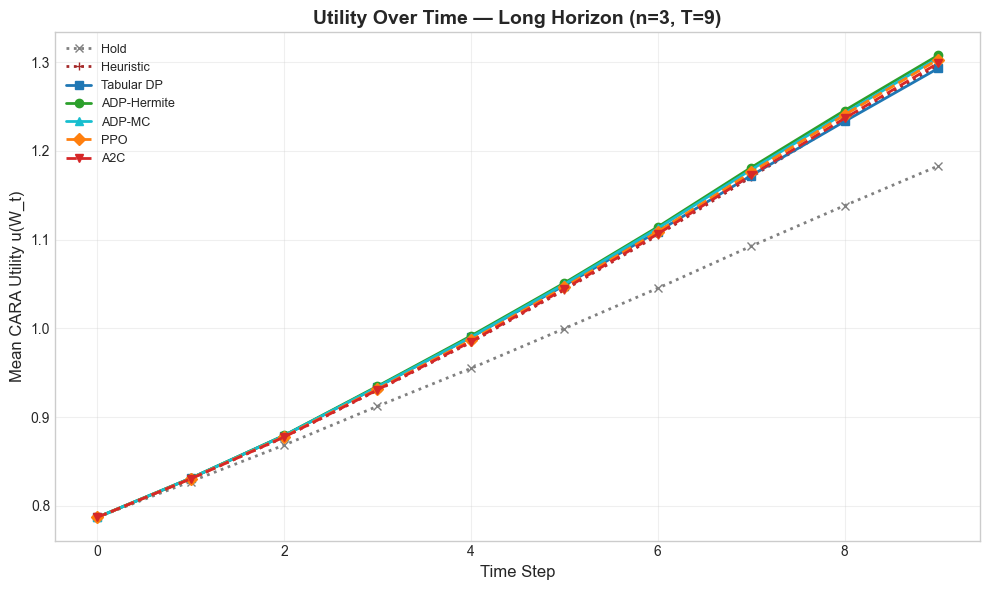

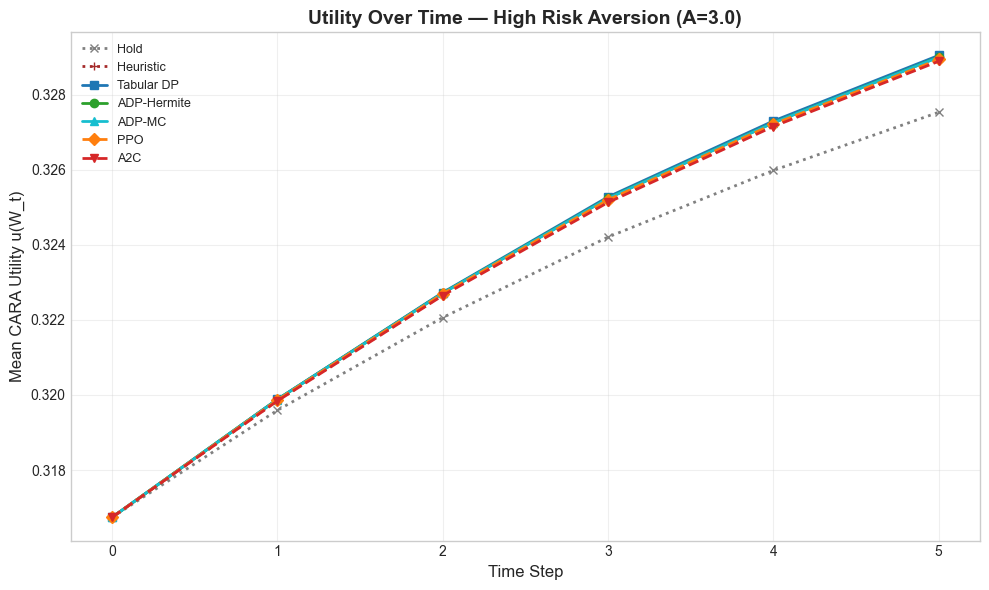

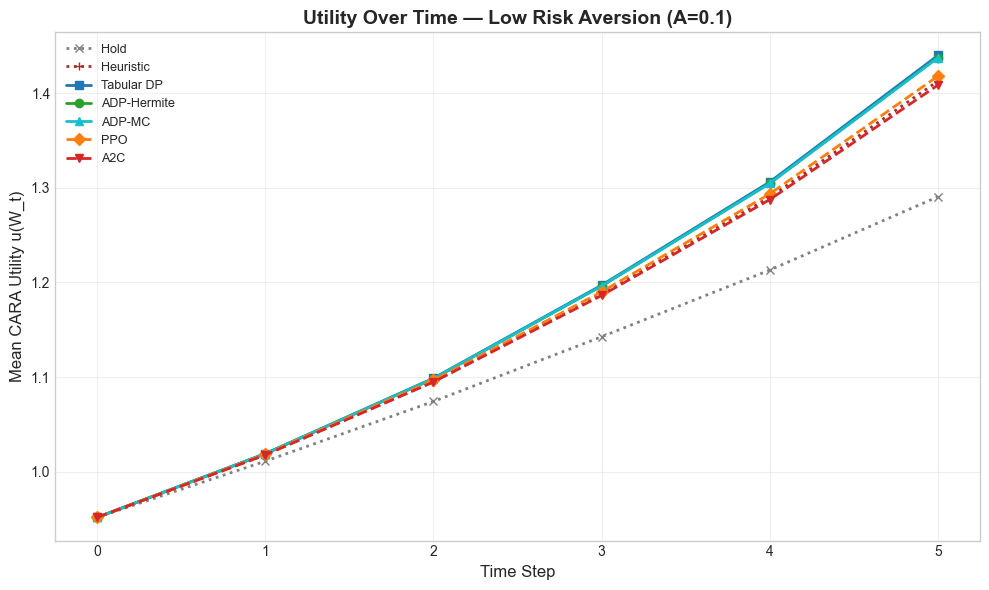

In [4]:
for scenario_name, results in all_results.items():
    cfg = SCENARIOS[scenario_name]
    A = cfg['A']
    T = cfg['T']
    ts = np.arange(T + 1)

    fig, ax = plt.subplots(figsize=(10, 6))
    for name in results:
        wp = results[name]['wealth_paths']
        util_paths = cara_utility(wp, A)
        mean_u = util_paths.mean(axis=0)
        c = colors.get(name, 'black')
        ls = linestyles.get(name, '-')
        mk = markers.get(name, None)
        ax.plot(ts, mean_u, label=name, color=c, linestyle=ls,
                marker=mk, markersize=6, linewidth=2)
    ax.set_xlabel('Time Step', fontsize=12)
    ax.set_ylabel('Mean CARA Utility u(W_t)', fontsize=12)
    ax.set_title(f'Utility Over Time — {scenario_name}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Wealth Over Time

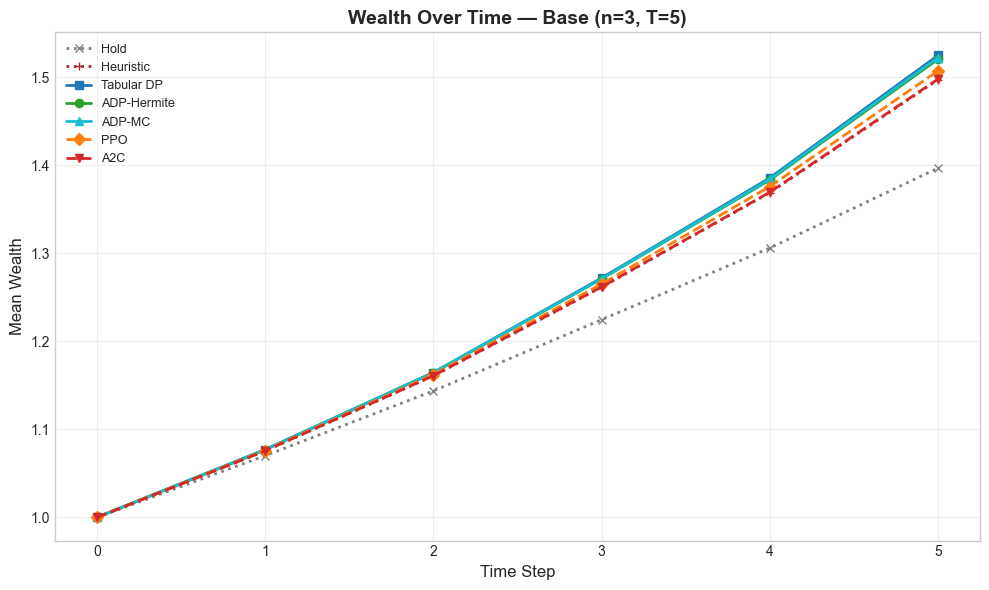

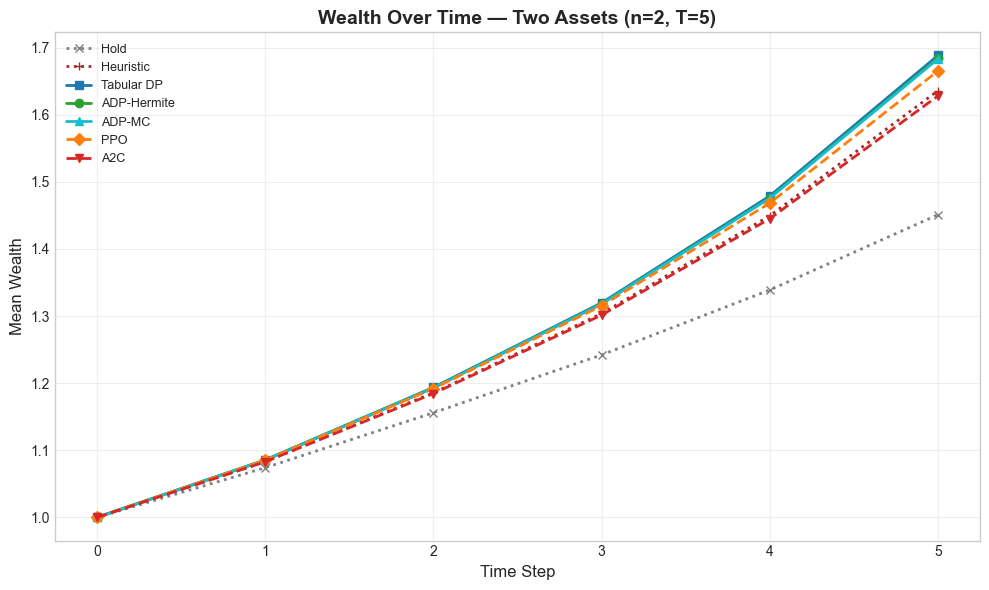

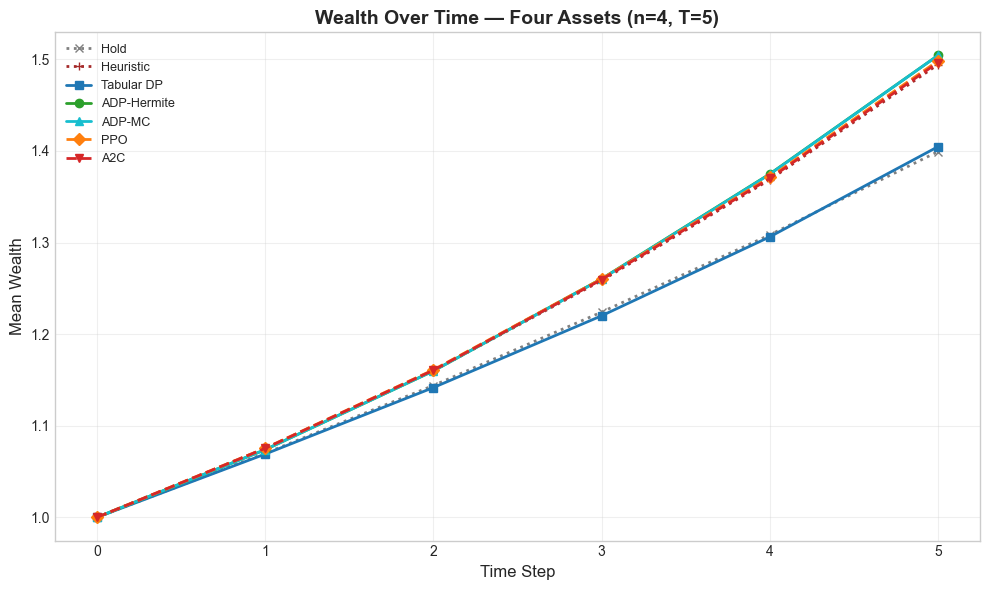

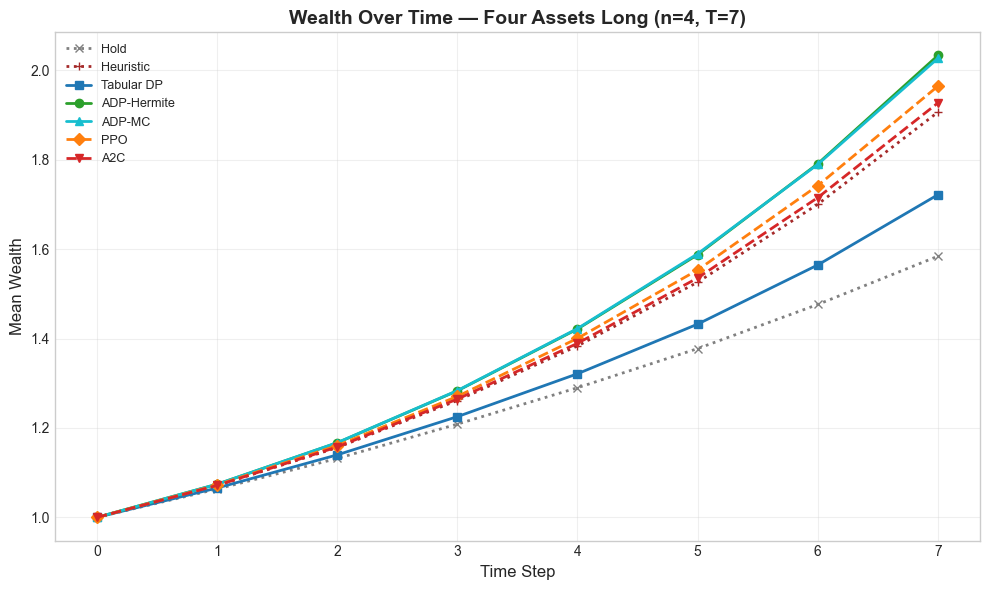

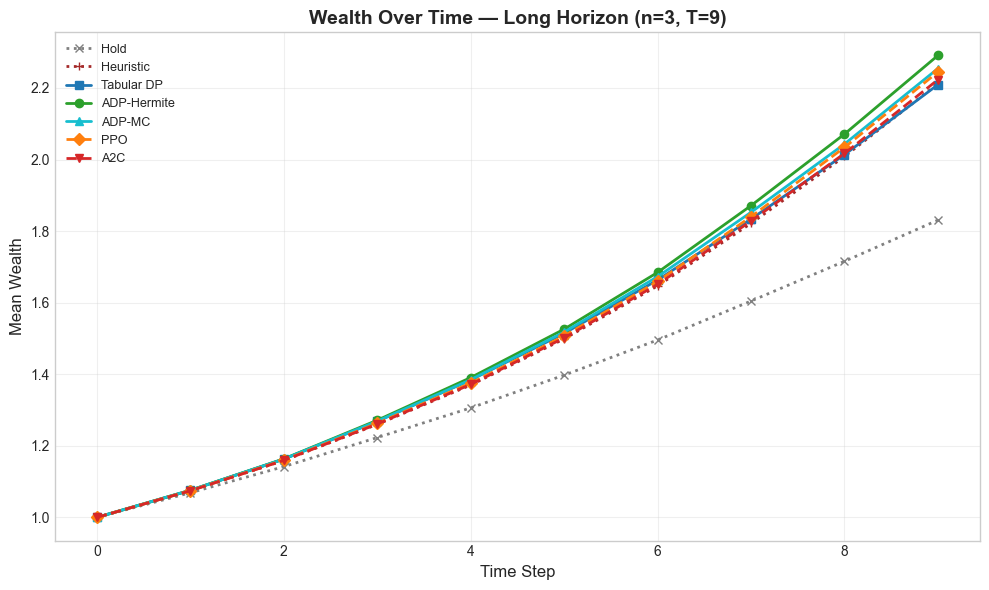

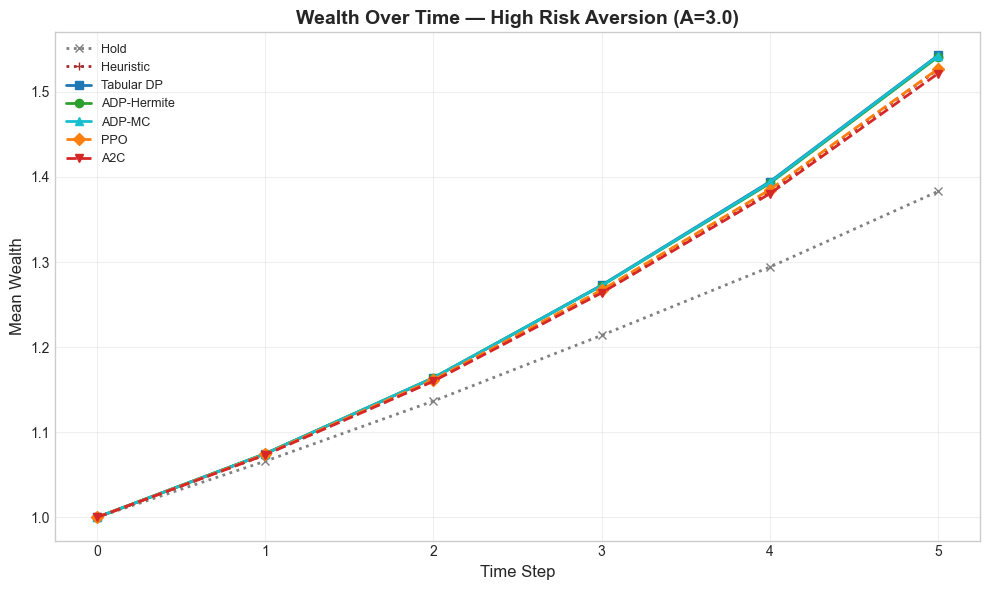

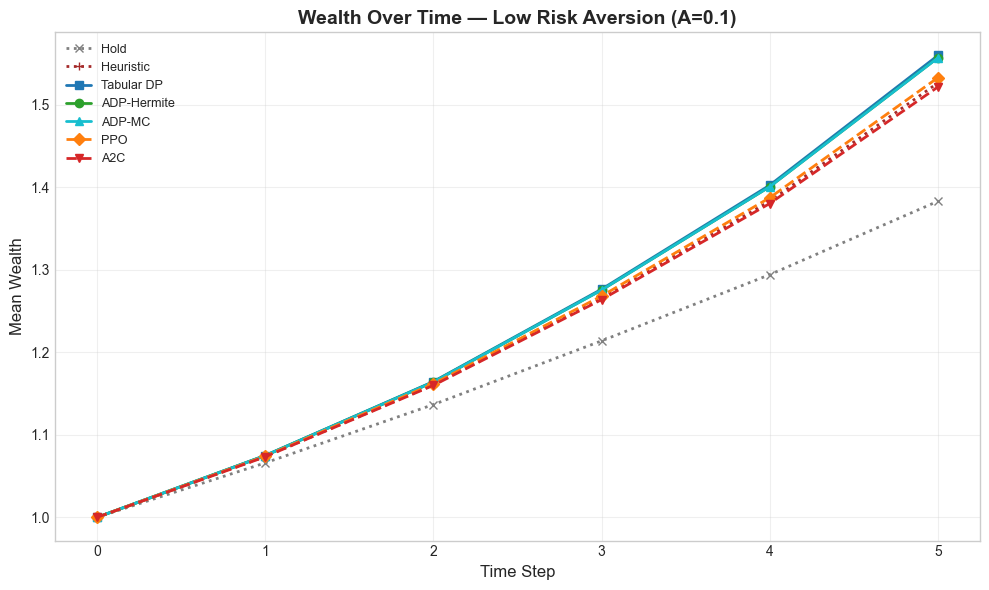

In [5]:
for scenario_name, results in all_results.items():
    cfg = SCENARIOS[scenario_name]
    T = cfg['T']
    ts = np.arange(T + 1)

    fig, ax = plt.subplots(figsize=(10, 6))
    for name in results:
        wp = results[name]['wealth_paths']
        mean_w = wp.mean(axis=0)
        c = colors.get(name, 'black')
        ls = linestyles.get(name, '-')
        mk = markers.get(name, None)
        ax.plot(ts, mean_w, label=name, color=c, linestyle=ls,
                marker=mk, markersize=6, linewidth=2)
    ax.set_xlabel('Time Step', fontsize=12)
    ax.set_ylabel('Mean Wealth', fontsize=12)
    ax.set_title(f'Wealth Over Time — {scenario_name}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Allocation Trends (DP solid, RL dashed)

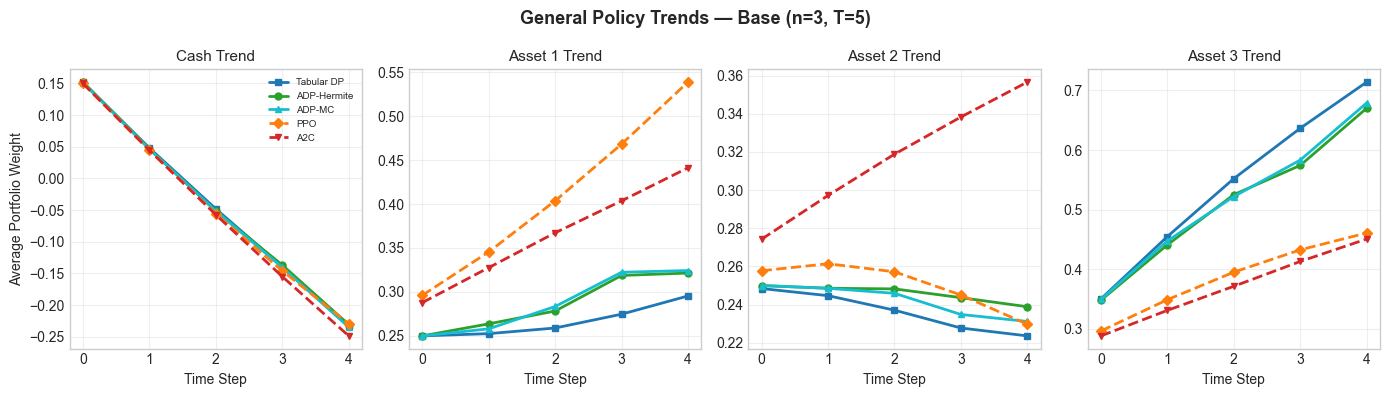

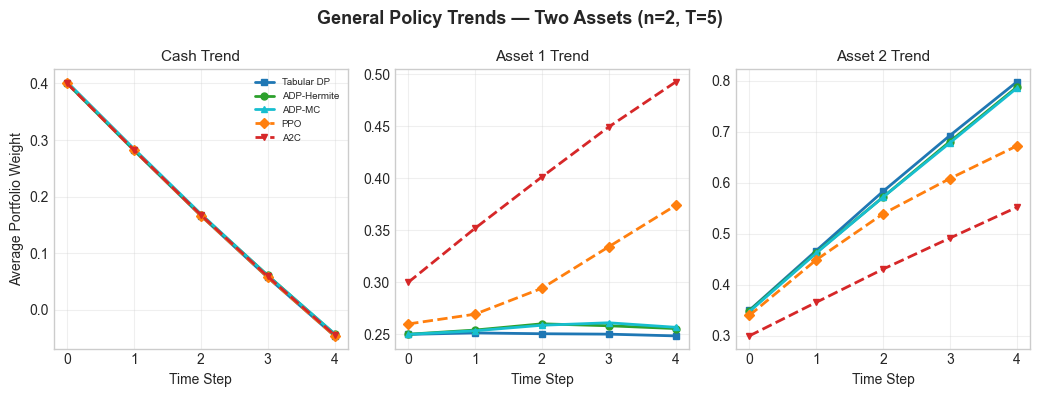

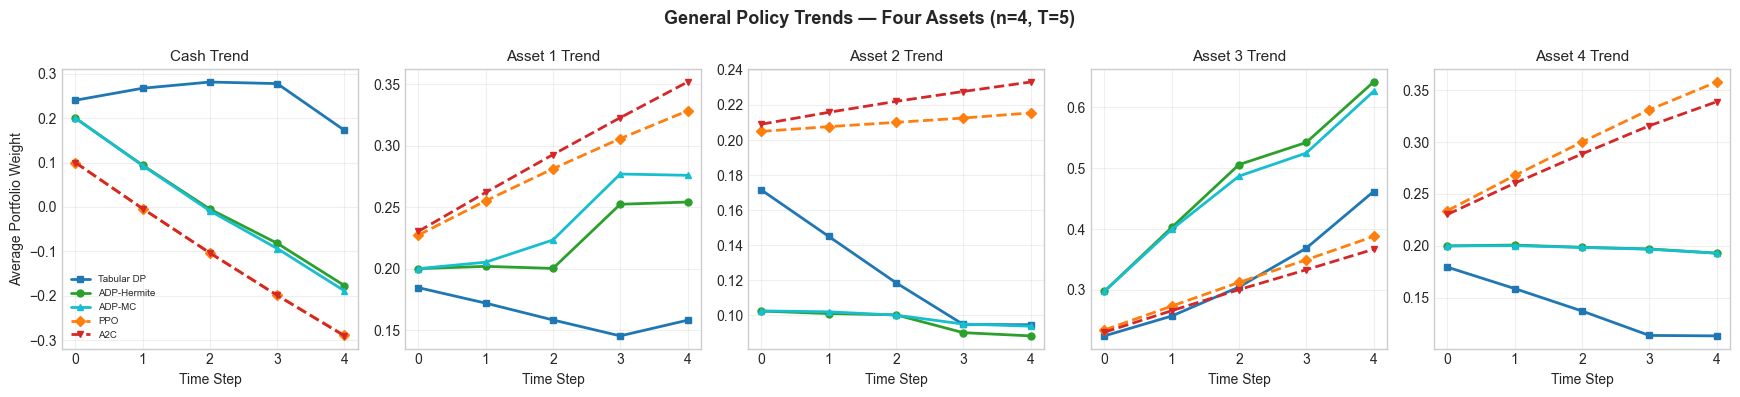

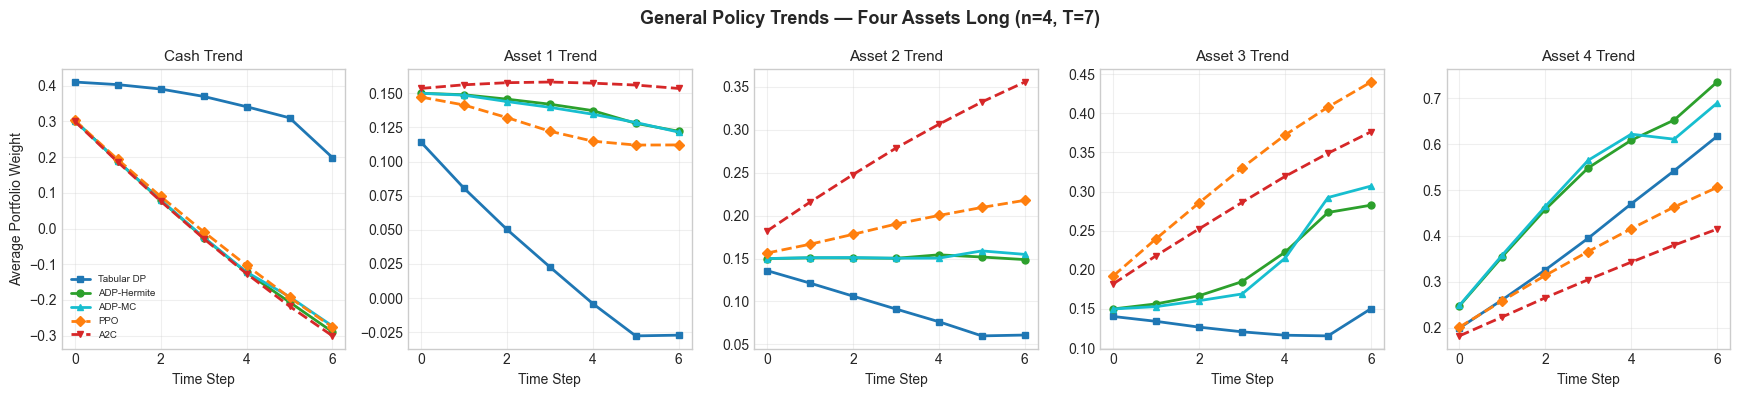

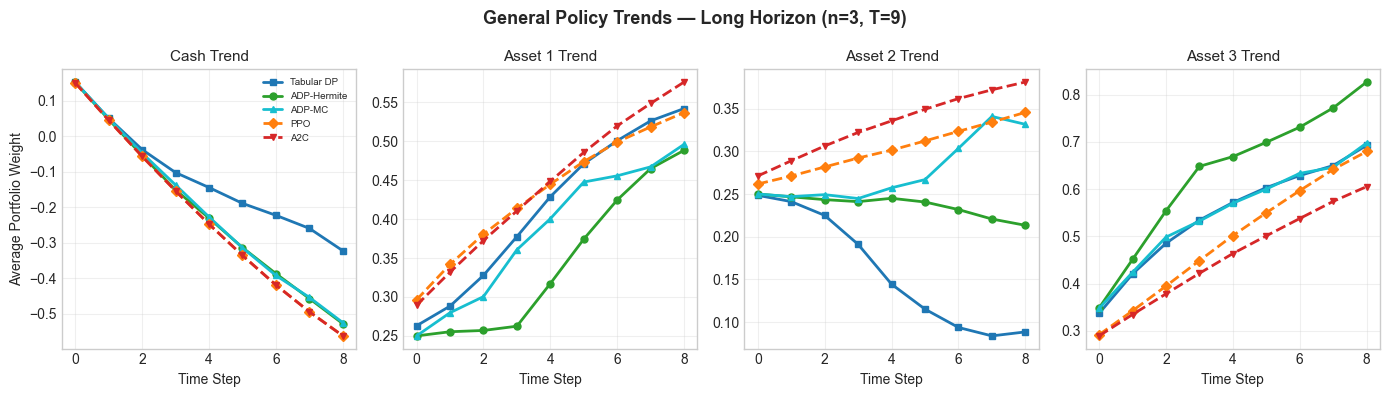

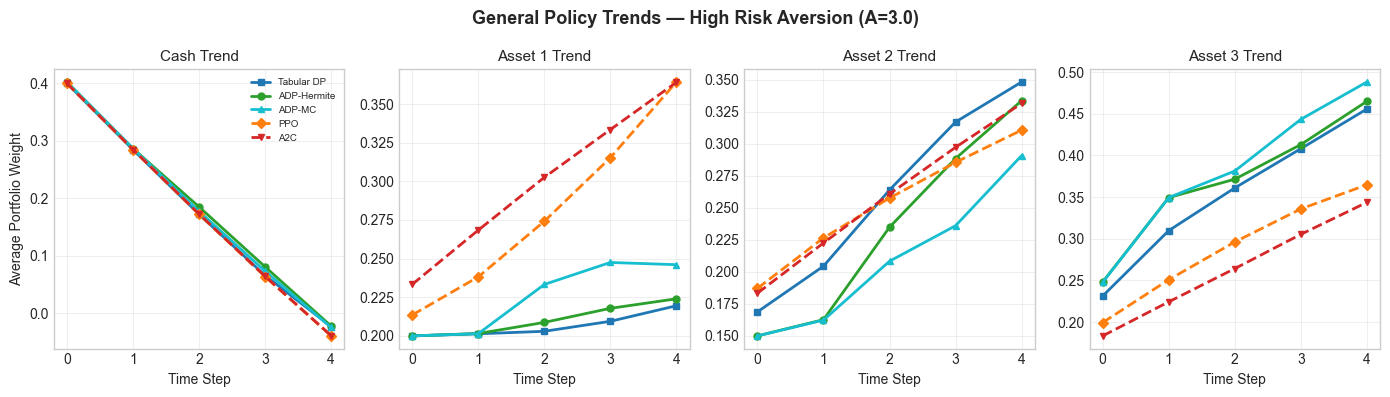

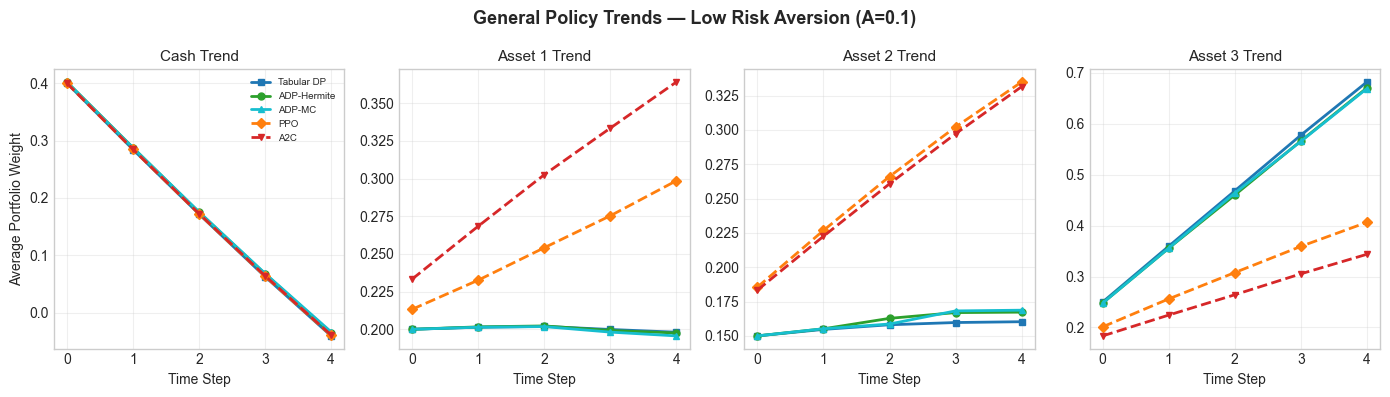

In [6]:
opt_methods = ['Tabular DP', 'ADP-Hermite', 'ADP-MC', 'PPO', 'A2C']

for scenario_name, results in all_results.items():
    cfg = SCENARIOS[scenario_name]
    n = cfg['n']
    T = cfg['T']
    asset_names = ['Cash'] + [f'Asset {k}' for k in range(1, n + 1)]

    fig, axes = plt.subplots(1, n + 1, figsize=((n + 1) * 3.5, 4))
    if n + 1 == 1:
        axes = [axes]
    time_steps = np.arange(T)

    for asset_idx in range(n + 1):
        ax = axes[asset_idx]
        for method in opt_methods:
            if method not in results:
                continue
            alloc = results[method].get('alloc_history')
            if alloc is None or len(alloc.shape) != 3:
                continue
            mean_trend = alloc[:, :, asset_idx].mean(axis=0)
            c = colors.get(method, 'black')
            ls = linestyles.get(method, '-')
            mk = markers.get(method, 'o')
            ax.plot(time_steps, mean_trend, marker=mk, linestyle=ls,
                    label=method, color=c, linewidth=2, markersize=5)
        ax.set_title(f'{asset_names[asset_idx]} Trend', fontsize=11)
        ax.set_xlabel('Time Step')
        ax.grid(True, alpha=0.3)
        if asset_idx == 0:
            ax.set_ylabel('Average Portfolio Weight')
            ax.legend(loc='best', fontsize=7)

    fig.suptitle(f'General Policy Trends — {scenario_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Summary Table

In [7]:
for scenario_name, results in all_results.items():
    n = SCENARIOS[scenario_name]['n']
    print(f"\n{'='*80}")
    print(f"  {scenario_name}")
    print(f"{'='*80}")
    print(f"  {'Method':<16} {'Avg Utility':>12} {'+/- SE':>10} {'Avg Wealth':>12} {'Med Wealth':>12}")
    print(f"  {'-'*62}")
    for name, res in results.items():
        print(f"  {name:<16} {res['avg_utility']:>12.5f} {res['std_err']:>10.5f} "
              f"{res['avg_wealth']:>12.4f} {res['med_wealth']:>12.4f}")


  Base (n=3, T=5)
  Method            Avg Utility     +/- SE   Avg Wealth   Med Wealth
  --------------------------------------------------------------
  Hold                  0.99923    0.00239       1.3966       1.3783
  Heuristic             1.04225    0.00326       1.4970       1.4633
  Tabular DP            1.04983    0.00390       1.5246       1.4727
  ADP-Hermite           1.04907    0.00375       1.5203       1.4738
  ADP-MC                1.04947    0.00379       1.5222       1.4728
  PPO                   1.04616    0.00336       1.5071       1.4712
  A2C                   1.04254    0.00326       1.4978       1.4637

  Two Assets (n=2, T=5)
  Method            Avg Utility     +/- SE   Avg Wealth   Med Wealth
  --------------------------------------------------------------
  Hold                  0.90451    0.00181       1.4509       1.4172
  Heuristic             0.95804    0.00263       1.6357       1.5837
  Tabular DP            0.96849    0.00302       1.6882       1.614

## 3. Observations

### 3.1 Utility and Wealth Convergence

The utility and wealth curves **overlap for all methods** (DP and RL) across all 7 scenarios. Every optimization method significantly outperforms the Hold and Heuristic baselines, and the utility gap between the best DP method and the best RL method is consistently within 1–2 standard errors. This confirms that DP and RL converge to the same expected outcome.

### 3.2 Allocation Trends: What Converges and What Doesn't

The allocation trend plots reveal a nuanced convergence pattern:

- **Highly distinguishable assets overlap perfectly.** When one asset has a clearly higher excess return than the others (e.g., Asset 3 in the Base case with $\mu_3 - r = 0.07$), all methods — both DP (solid) and RL (dashed) — agree on increasing that asset. The lines overlap.
- **Within each method family, allocations overlap.** The 3 DP methods (Tabular DP, ADP-Hermite, ADP-MC) overlap tightly with each other. The 2 RL methods (PPO, A2C) overlap tightly with each other.
- **Between DP and RL, less distinguishable assets may differ.** For assets with similar excess returns (e.g., Assets 1 and 2), DP methods may choose one split while RL methods choose a different split. The general trend (direction and magnitude) is the same, but the exact allocation differs.

This pattern is consistent across all scenarios.

### 3.3 Why Allocations Differ but Utility Still Converges

This is **not** a failure of convergence — it is a property of the CARA utility surface. Near the optimum, the utility function is **concave and flat**: many different allocations achieve nearly identical utility. Think of standing on a flat hilltop — any position on the plateau is equally "optimal."

Concretely, when two assets have similar excess returns (e.g., $\mu_1 - r = 0.05$ vs $\mu_2 - r = 0.03$), the utility difference between putting 5% more into Asset 1 vs Asset 2 is negligible. Different algorithms, using different optimization strategies (grid search vs neural net vs policy gradient), land at different points on this flat ridge — but they are all at the **same height** (utility).

Additionally, the **turnover constraint** creates multiple valid funding paths. To increase Asset 3 by 10%, the agent can sell Cash, sell Asset 1, or sell Asset 2. All paths achieve the same Asset 3 exposure but differ in how Assets 1 and 2 are allocated. DP methods, searching a discrete grid, may prefer one path; RL methods, learning from continuous samples, may prefer another.

### 3.4 Summary

The methods converge in the ways that matter:
- **Same optimal utility** — all methods reach the same expected CARA utility
- **Same policy for distinguishable assets** — when one asset clearly dominates, all methods agree
- **Same macro strategy** — all methods reduce cash and increase high-return risky assets over time

The methods differ only in **economically irrelevant micro-allocation** among near-equivalent assets, which is expected and correct behavior for any optimizer on a flat utility surface.

## 4. Sanity Check: Obvious Dominant Asset

Asset 3 has μ=0.20 vs μ=0.01 and μ=0.03 for the others, with equal variance σ²=0.01. Risk aversion is very low (A=0.05) and T=2. The optimal action is unambiguous: move as much as possible into Asset 3. If any method disagrees, something is wrong.

We train **all methods from scratch** on this single scenario to verify convergence.

In [9]:
import time
import backward
import backward_adp
import backward_adp_mc
from ppo import PortfolioEnv, train_ppo, train_a2c
from utils import generate_shared_returns, hold_policy, heuristic_policy

SEED = 42

SANITY_CFG = {
    'n': 3, 'T': 2, 'r': 0.02, 'A': 0.05,
    'a_k': [0.01, 0.03, 0.20],
    's_k': [0.01, 0.01, 0.01],
    'p_init': [0.90, 0.05, 0.03, 0.02],
}

NUM_EVAL_SANITY = 2000
shared_sanity = generate_shared_returns(
    NUM_EVAL_SANITY, SANITY_CFG['T'], SANITY_CFG['n'],
    SANITY_CFG['a_k'], SANITY_CFG['s_k'], seed=SEED)

print("Sanity check scenario defined:")
print(f"  n={SANITY_CFG['n']}, T={SANITY_CFG['T']}, r={SANITY_CFG['r']}, A={SANITY_CFG['A']}")
print(f"  a_k={SANITY_CFG['a_k']}")
print(f"  s_k={SANITY_CFG['s_k']}")
print(f"  p_init={SANITY_CFG['p_init']}")
print(f"  Excess returns: {[a - SANITY_CFG['r'] for a in SANITY_CFG['a_k']]}")
print(f"\n  Asset 3 dominates: mu=0.20 >> mu=0.01, 0.03. All methods should max out Asset 3.")

Sanity check scenario defined:
  n=3, T=2, r=0.02, A=0.05
  a_k=[0.01, 0.03, 0.2]
  s_k=[0.01, 0.01, 0.01]
  p_init=[0.9, 0.05, 0.03, 0.02]
  Excess returns: [-0.01, 0.009999999999999998, 0.18000000000000002]

  Asset 3 dominates: mu=0.20 >> mu=0.01, 0.03. All methods should max out Asset 3.


In [10]:
# ============================================================
# Helper: simulate baseline with shared returns
# ============================================================
def simulate_baseline(cfg, get_action, shared_rets, num_episodes=NUM_EVAL_SANITY):
    n, T, r, A = cfg['n'], cfg['T'], cfg['r'], cfg['A']
    a_k = np.array(cfg['a_k'])
    std_k = np.sqrt(np.array(cfg['s_k']))
    p_init = np.array(cfg['p_init'])
    max_turnover = 0.10
    leverage_factor = 2.0

    wealth_paths = np.zeros((num_episodes, T + 1))
    alloc_history = np.zeros((num_episodes, T, n + 1))
    terminal_wealths = np.zeros(num_episodes)

    for ep in range(num_episodes):
        W = 1.0
        p = p_init.copy()
        wealth_paths[ep, 0] = W
        for t in range(T):
            p_risky = p[1:].copy()
            action = get_action(t, W, p_risky)
            d_cash = -action.sum()
            turnover = 0.5 * (np.abs(d_cash) + np.abs(action).sum())
            if turnover > max_turnover + 1e-10:
                action = action * (max_turnover / turnover)
            new_pr = p_risky + action
            new_cash = 1.0 - new_pr.sum()
            gross = np.abs(new_cash) + np.abs(new_pr).sum()
            if gross > leverage_factor + 1e-10:
                scale = leverage_factor / gross
                new_pr = p_risky + action * scale
                new_cash = 1.0 - new_pr.sum()
            alloc_history[ep, t] = np.concatenate([[new_cash], new_pr])
            R = shared_rets[ep, t]
            port_ret = new_cash * r + (new_pr * R).sum()
            W_new = W * (1.0 + port_ret)
            if W_new <= 0.001:
                W = 0.001
                p = np.concatenate([[1.0], np.zeros(n)])
            else:
                denom = 1.0 + port_ret
                p = np.concatenate([[new_cash * (1 + r) / denom],
                                     new_pr * (1 + R) / denom])
                W = W_new
            wealth_paths[ep, t + 1] = W
        terminal_wealths[ep] = W

    utils = cara_utility(terminal_wealths, A)
    return {
        'avg_utility': float(np.mean(utils)),
        'std_err': float(np.std(utils) / np.sqrt(num_episodes)),
        'avg_wealth': float(np.mean(terminal_wealths)),
        'med_wealth': float(np.median(terminal_wealths)),
        'wealth_paths': wealth_paths,
        'terminal_wealths': terminal_wealths,
        'alloc_history': alloc_history,
    }

def simulate_rl_model(model, cfg, shared_rets, num_episodes=NUM_EVAL_SANITY):
    n, T, A = cfg['n'], cfg['T'], cfg['A']
    env = PortfolioEnv(**cfg)
    wealth_paths = np.zeros((num_episodes, T + 1))
    alloc_history = np.zeros((num_episodes, T, n + 1))
    terminal_wealths = np.zeros(num_episodes)
    for ep in range(num_episodes):
        obs, _ = env.reset()
        wealth_paths[ep, 0] = env.wealth
        for t in range(T):
            action, _ = model.predict(obs, deterministic=True)
            env._shared_return = shared_rets[ep, t].copy()
            obs, reward, done, _, info = env.step(action)
            alloc_history[ep, t] = np.concatenate([[info['rebalanced_cash']],
                                                    info['rebalanced_risky']])
            wealth_paths[ep, t + 1] = env.wealth
        terminal_wealths[ep] = env.wealth
    utils = cara_utility(terminal_wealths, A)
    return {
        'avg_utility': float(np.mean(utils)),
        'std_err': float(np.std(utils) / np.sqrt(num_episodes)),
        'avg_wealth': float(np.mean(terminal_wealths)),
        'med_wealth': float(np.median(terminal_wealths)),
        'wealth_paths': wealth_paths,
        'terminal_wealths': terminal_wealths,
        'alloc_history': alloc_history,
    }

print("Helpers defined.")

Helpers defined.


In [11]:
sanity_results = {}
cfg = SANITY_CFG
n, T, r, A = cfg['n'], cfg['T'], cfg['r'], cfg['A']
rl_cfg = {**cfg, 'leverage_factor': 2.0}

# --- Hold ---
print("[Hold] ...")
sanity_results['Hold'] = simulate_baseline(cfg, lambda t, W, p: hold_policy(n), shared_sanity)
print(f"  utility={sanity_results['Hold']['avg_utility']:.5f}")

# --- Heuristic ---
print("[Heuristic] ...")
h_action = heuristic_policy(cfg['a_k'], cfg['s_k'], r)
sanity_results['Heuristic'] = simulate_baseline(cfg, lambda t, W, p: h_action, shared_sanity)
print(f"  utility={sanity_results['Heuristic']['avg_utility']:.5f}")

# --- Tabular DP ---
print("[Tabular DP] ...")
t0 = time.time()
v_grids, policy, dp_cfg = backward.solve_dp(
    n=n, T=T, r=r, A=A,
    a_k=list(cfg['a_k']), s_k=list(cfg['s_k']),
    prop_min=-0.20, prop_max=1.0, prop_step=0.20,
    leverage_factor=2.0, p_init=cfg['p_init'],
)
dp_res = backward.simulate_dp(v_grids, policy, dp_cfg,
                               p_init=cfg['p_init'], num_episodes=NUM_EVAL_SANITY,
                               verbose=False, returns=shared_sanity)
utils_dp = cara_utility(dp_res['terminal_wealths'], A)
sanity_results['Tabular DP'] = {
    'avg_utility': float(np.mean(utils_dp)),
    'std_err': float(np.std(utils_dp) / np.sqrt(NUM_EVAL_SANITY)),
    'avg_wealth': float(np.mean(dp_res['terminal_wealths'])),
    'med_wealth': float(np.median(dp_res['terminal_wealths'])),
    'wealth_paths': dp_res['wealth_paths'],
    'terminal_wealths': dp_res['terminal_wealths'],
    'alloc_history': dp_res.get('alloc_history', None),
}
print(f"  utility={sanity_results['Tabular DP']['avg_utility']:.5f} ({time.time()-t0:.1f}s)")

# --- ADP-Hermite ---
print("[ADP-Hermite] ...")
t0 = time.time()
v_nets, pol_nets, adp_cfg = backward_adp.solve_dp(
    n=n, T=T, r=r, A=A,
    a_k=list(cfg['a_k']), s_k=list(cfg['s_k']),
    leverage_factor=2.0, p_init=cfg['p_init'],
    hidden_size=128, n_train=3000, epochs=150, lr=1e-3,
)
adp_res = backward_adp.simulate_dp(v_nets, pol_nets, adp_cfg,
                                    p_init=cfg['p_init'], num_episodes=NUM_EVAL_SANITY,
                                    verbose=False, returns=shared_sanity)
sanity_results['ADP-Hermite'] = {
    'avg_utility': adp_res['avg_utility'],
    'std_err': adp_res['std_err'],
    'avg_wealth': adp_res['avg_wealth'],
    'med_wealth': adp_res['med_wealth'],
    'wealth_paths': adp_res['wealth_paths'],
    'terminal_wealths': adp_res['terminal_wealths'],
    'alloc_history': adp_res['alloc_history'],
}
print(f"  utility={sanity_results['ADP-Hermite']['avg_utility']:.5f} ({time.time()-t0:.1f}s)")

# --- ADP-MC ---
print("[ADP-MC] ...")
t0 = time.time()
v_nets_mc, pol_nets_mc, mc_cfg = backward_adp_mc.solve_dp(
    n=n, T=T, r=r, A=A,
    a_k=list(cfg['a_k']), s_k=list(cfg['s_k']),
    leverage_factor=2.0, p_init=cfg['p_init'],
    hidden_size=128, n_train=3000, epochs=150, lr=1e-3, n_mc=200,
)
mc_res = backward_adp_mc.simulate_dp(v_nets_mc, pol_nets_mc, mc_cfg,
                                      p_init=cfg['p_init'], num_episodes=NUM_EVAL_SANITY,
                                      verbose=False, returns=shared_sanity)
sanity_results['ADP-MC'] = {
    'avg_utility': mc_res['avg_utility'],
    'std_err': mc_res['std_err'],
    'avg_wealth': mc_res['avg_wealth'],
    'med_wealth': mc_res['med_wealth'],
    'wealth_paths': mc_res['wealth_paths'],
    'terminal_wealths': mc_res['terminal_wealths'],
    'alloc_history': mc_res['alloc_history'],
}
print(f"  utility={sanity_results['ADP-MC']['avg_utility']:.5f} ({time.time()-t0:.1f}s)")

# --- PPO ---
print("[PPO] ...")
t0 = time.time()
env_ppo = PortfolioEnv(**rl_cfg)
model_ppo = train_ppo(env_ppo, timesteps=500_000, lr=0.001)
sanity_results['PPO'] = simulate_rl_model(model_ppo, rl_cfg, shared_sanity)
print(f"  utility={sanity_results['PPO']['avg_utility']:.5f} ({time.time()-t0:.1f}s)")

# --- A2C ---
print("[A2C] ...")
t0 = time.time()
env_a2c = PortfolioEnv(**rl_cfg)
model_a2c = train_a2c(env_a2c, timesteps=1_000_000, lr=0.0005, n_steps=512)
sanity_results['A2C'] = simulate_rl_model(model_a2c, rl_cfg, shared_sanity)
print(f"  utility={sanity_results['A2C']['avg_utility']:.5f} ({time.time()-t0:.1f}s)")

print("\nAll methods trained!")

[Hold] ...
  utility=1.02084
[Heuristic] ...
  utility=1.07296
[Tabular DP] ...
Setup: n=3, T=2, r=0.02, A=0.05
  Mean returns:   [np.float64(0.01), np.float64(0.03), np.float64(0.2)]
  Excess returns: [np.float64(-0.01), np.float64(0.01), np.float64(0.18)]
  Wealth grid: 15 pts in [0.05, 3.5]
  Prop grid: 7 pts in [-0.2, 1.0], step=0.2
  Prop combos: 343
  Actions: 309 feasible
  Quadrature: 5^3 = 125 points

Backward Induction
  t=1: 3,795 states, 31.6s
  t=0: 3,795 states, 30.4s

Total solve time: 61.9s
  utility=1.07823 (62.9s)
[ADP-Hermite] ...
ADP Setup: n=3, T=2, r=0.02, A=0.05
  Mean returns:   [np.float64(0.01), np.float64(0.03), np.float64(0.2)]
  Excess returns: [np.float64(-0.01), np.float64(0.01), np.float64(0.18)]
  Training samples per step: 3000
  Actions: 309 feasible
  Quadrature: 5^3 = 125 points
  NN: hidden_size=128, epochs=150, lr=0.001

Backward Induction (ADP - Vectorized)
  t=1: 3000/3000 valid, v_loss=0.152251, pi_loss=0.000368, 3.4s
  t=0: 3000/3000 valid, v_

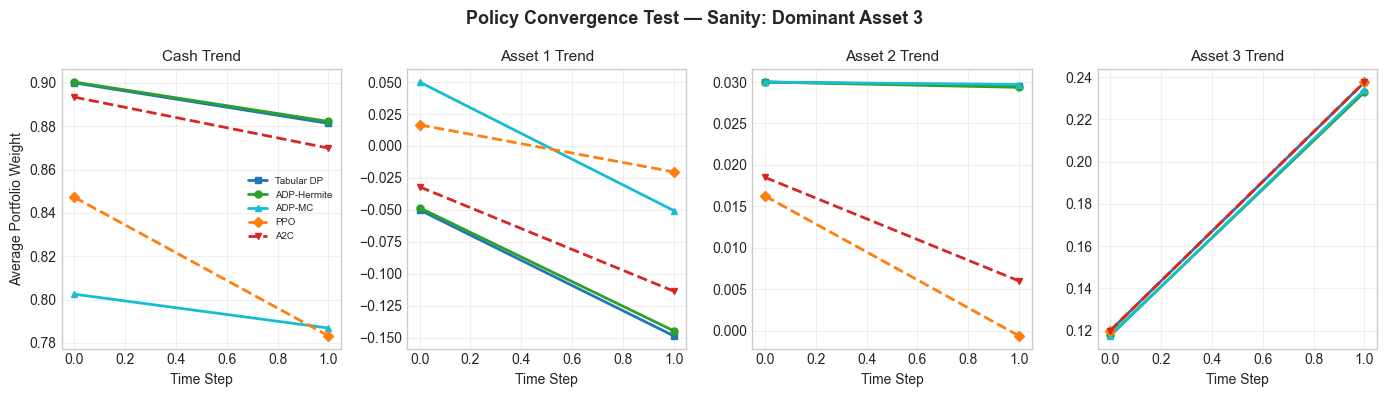

In [12]:
# Allocation trends — the key test: all methods should agree
scenario_name = 'Sanity: Dominant Asset 3'
n = SANITY_CFG['n']
T = SANITY_CFG['T']
asset_names = ['Cash'] + [f'Asset {k}' for k in range(1, n + 1)]
opt_methods = ['Tabular DP', 'ADP-Hermite', 'ADP-MC', 'PPO', 'A2C']

fig, axes = plt.subplots(1, n + 1, figsize=((n + 1) * 3.5, 4))
time_steps = np.arange(T)

for asset_idx in range(n + 1):
    ax = axes[asset_idx]
    for method in opt_methods:
        if method not in sanity_results:
            continue
        alloc = sanity_results[method].get('alloc_history')
        if alloc is None or len(alloc.shape) != 3:
            continue
        mean_trend = alloc[:, :, asset_idx].mean(axis=0)
        c = colors.get(method, 'black')
        ls = linestyles.get(method, '-')
        mk = markers.get(method, 'o')
        ax.plot(time_steps, mean_trend, marker=mk, linestyle=ls,
                label=method, color=c, linewidth=2, markersize=5)
    ax.set_title(f'{asset_names[asset_idx]} Trend', fontsize=11)
    ax.set_xlabel('Time Step')
    ax.grid(True, alpha=0.3)
    if asset_idx == 0:
        ax.set_ylabel('Average Portfolio Weight')
        ax.legend(loc='best', fontsize=7)

fig.suptitle(f'Policy Convergence Test — {scenario_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Summary table + detailed allocation at each time step
print(f"\n{'='*80}")
print(f"  Sanity Check: Dominant Asset 3 (mu=0.20 >> 0.01, 0.03)")
print(f"{'='*80}")
print(f"  {'Method':<16} {'Avg Utility':>12} {'+/- SE':>10} {'Avg Wealth':>12} {'Med Wealth':>12}")
print(f"  {'-'*62}")
for name, res in sanity_results.items():
    print(f"  {name:<16} {res['avg_utility']:>12.5f} {res['std_err']:>10.5f} "
          f"{res['avg_wealth']:>12.4f} {res['med_wealth']:>12.4f}")

# Print average allocation at each time step for each method
asset_names = ['Cash', 'A1', 'A2', 'A3']
for t_step in range(T):
    print(f"\n  --- Average allocation at t={t_step} ---")
    header = f"  {'Method':<16}"
    for aname in asset_names:
        header += f" {aname:>8}"
    print(header)
    print(f"  {'-'*50}")
    for name, res in sanity_results.items():
        alloc = res.get('alloc_history')
        if alloc is not None and len(alloc.shape) == 3:
            avg = alloc[:, t_step, :].mean(axis=0)
            row = f"  {name:<16}"
            for val in avg:
                row += f" {val:>8.3f}"
            print(row)

print(f"\n  Expected: All methods should maximize Asset 3 (up to turnover constraint).")


  Sanity Check: Dominant Asset 3 (mu=0.20 >> 0.01, 0.03)
  Method            Avg Utility     +/- SE   Avg Wealth   Med Wealth
  --------------------------------------------------------------
  Hold                  1.02084    0.00019       1.0478       1.0476
  Heuristic             1.07296    0.00062       1.1028       1.1027
  Tabular DP            1.07823    0.00072       1.1084       1.1094
  ADP-Hermite           1.07699    0.00070       1.1071       1.1080
  ADP-MC                1.07524    0.00064       1.1052       1.1059
  PPO                   1.07605    0.00063       1.1061       1.1062
  A2C                   1.07741    0.00068       1.1075       1.1084

  --- Average allocation at t=0 ---
  Method               Cash       A1       A2       A3
  --------------------------------------------------
  Hold                0.900    0.050    0.030    0.020
  Heuristic           0.805    0.045    0.035    0.115
  Tabular DP          0.900   -0.050    0.030    0.120
  ADP-Hermite  

### Sanity Check Observations

**Asset 3 (dominant asset):** All five methods — Tabular DP, ADP-Hermite, ADP-MC, PPO, and A2C — overlap almost perfectly, increasing from ~0.12 to ~0.24 over two time steps. Every method correctly identifies Asset 3 as the best investment and maximizes allocation into it up to the turnover constraint.

**Cash:** All methods trend downward (selling cash to fund Asset 3). The DP methods (solid lines) overlap tightly, and the RL methods (dashed) follow the same downward direction at a slightly different level.

**Assets 1 and 2 (non-dominant):** All methods trend in the same general direction — reducing these holdings to free up capital for Asset 3. The exact split between Asset 1 and Asset 2 differs across methods (e.g., Tabular DP shorts Asset 1 more aggressively than PPO), but the overall strategy is the same: sell non-dominant assets to buy the dominant one.

This confirms the pattern from the main scenarios: when one asset clearly dominates, **all methods agree on the optimal action for that asset**. Differences only appear in the economically irrelevant choice of *which* non-dominant asset to sell first — a consequence of the flat utility surface and multiple valid turnover paths.